# 5. Quantum machine learning for security screening

**Reading time: about 30 minutes. Prerequisite: notebook 1.**

The third family of quantum algorithms with power system applications is machine
learning. This notebook covers two tasks:

* **Classification** — decide whether an operating point is N-1 secure, using a
  quantum kernel against a classical one. The result is a warning: the quantum
  kernel’s accuracy swings from competitive to chance level on a single
  hyperparameter, and this notebook measures that swing.
* **Generation** — learn the joint distribution of wind profiles with a quantum
  Boltzmann machine, which is the model behind scenario generation for
  stochastic scheduling.

Both use datasets built from real power flow, not synthetic blobs.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import qugrid as qg
from qugrid.problems import binarize, empirical_statistics, screening_dataset, toy_wind_profiles
from qugrid.solvers import (
    QuantumBoltzmannMachine,
    compare_kernels,
    quantum_kernel,
    rbf_kernel,
    scale_features,
)

qg.viz.use_style()
np.set_printoptions(precision=4, suppress=True)

## 5.1 N-1 security screening as a classification task

**What operators do.** The N-1 criterion requires the system to survive the loss
of any single element. Checking it means running a power flow for every credible
contingency, at every operating point of interest. In planning studies and in
stochastic scheduling, “every operating point of interest” runs to thousands of
load and generation patterns, and each one carries a full contingency sweep.
That is why fast surrogate classifiers are studied: a model that flags the small
fraction of patterns needing a full sweep would remove most of the work.

**What the label means.** An operating point is labelled *insecure* when the
maximum branch loading — flow divided by the branch MVA rating — exceeds a
threshold in the base case or in any single-branch outage that leaves the
network connected. Outages that split the network are excluded, because the DC
flow on a disconnected system is not defined.

**What the features are.** One load multiplier per load bus. On the WSCC 9-bus
system there are three load buses, so three features. Each sample scales those
loads independently and scales generation to keep the balance.

In [2]:
net = qg.cases.case9()
data = screening_dataset(net, n_samples=200, threshold=1.0, seed=0)

print("network            :", data.net_name)
print("features           :", data.feature_names)
print("samples            :", data.x.shape)
print("loading threshold  :", data.threshold)
print("contingencies       :", data.contingencies, f"({len(data.contingencies)} branch outages)")
print("insecure fraction  :", round(float(data.y.mean()), 3))

network            : case9
features           : ['load_bus5', 'load_bus7', 'load_bus9']
samples            : (200, 3)
loading threshold  : 1.0
contingencies       : [1, 2, 4, 5, 7, 8] (6 branch outages)
insecure fraction  : 0.465


Six of the nine branches can be switched out while leaving the network
connected; the other three are bridges. Each sample therefore costs seven DC
power flows: the base case plus six contingencies.

The labels are not a black box. Reproduce one by hand.

In [3]:
sample = 0
multipliers = data.x[sample]
scaling = np.ones(net.n_bus)
scaling[np.flatnonzero(net.bus[:, 2] > 0)] = multipliers
stressed = net.scale_loads(scaling)
stressed.gen[:, 1] *= stressed.load_p.sum() / net.load_p.sum()

worst = qg.classical.solve_dc(stressed).max_loading()
worst_case = "base case"
for branch in data.contingencies:
    loading = qg.classical.solve_dc(stressed.drop_branch(branch)).max_loading()
    if loading > worst:
        worst, worst_case = loading, f"outage of branch {branch}"

print("load multipliers      :", multipliers)
print("worst branch loading  :", round(worst, 4), "from", worst_case)
print("label from the dataset:", data.y[sample], " (1 = insecure)")
print("label recomputed here :", int(worst > data.threshold))

load multipliers      : [1.1096 0.8158 0.6328]
worst branch loading  : 0.8236 from outage of branch 7
label from the dataset: 0  (1 = insecure)
label recomputed here : 0


In [4]:
train_x, train_y, test_x, test_y = data.split(train_fraction=0.7, seed=1)
print("training samples:", train_x.shape, " insecure fraction", round(float(train_y.mean()), 3))
print("test samples    :", test_x.shape, " insecure fraction", round(float(test_y.mean()), 3))

majority = float(max(test_y.mean(), 1 - test_y.mean()))
print("majority-class test accuracy (the chance baseline):", round(majority, 3))

training samples: (140, 3)  insecure fraction 0.443
test samples    : (60, 3)  insecure fraction 0.517
majority-class test accuracy (the chance baseline): 0.517


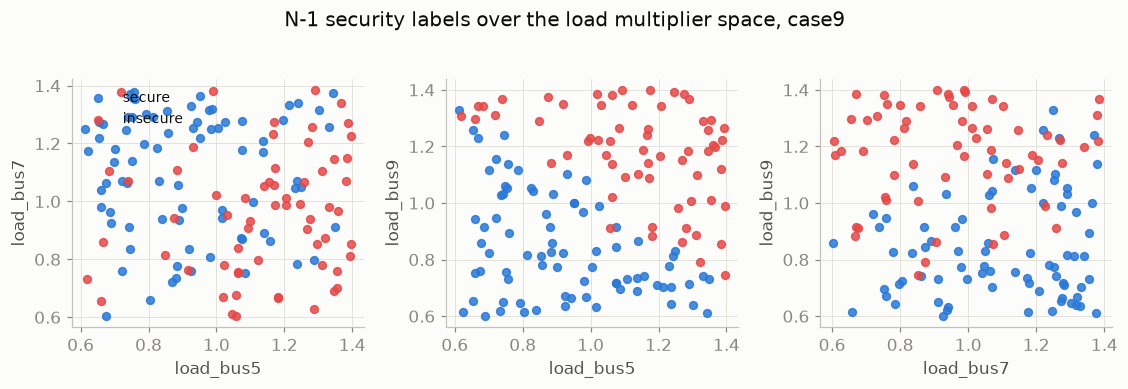

In [5]:
pairs = [(0, 1), (0, 2), (1, 2)]
classes = ((0, qg.viz.PALETTE[0], "secure"), (1, qg.viz.PALETTE[7], "insecure"))
fig, axes = plt.subplots(1, 3, figsize=(10.4, 3.4))
for ax, (i, j) in zip(axes, pairs):
    for label, colour, name in classes:
        mask = train_y == label
        ax.scatter(train_x[mask, i], train_x[mask, j], s=26, color=colour, label=name, alpha=0.85)
    ax.set_xlabel(data.feature_names[i])
    ax.set_ylabel(data.feature_names[j])
axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("N-1 security labels over the load multiplier space, case9", y=1.03)
plt.tight_layout()
plt.show()

The classes separate along a boundary that is close to, but not exactly, a
straight line in each projection: heavier loading is more often insecure, and
the load at bus 5 matters more than the others. This is a genuine but easy
classification problem, which is what a benchmark for kernel methods should be.

## 5.2 Kernels, quantum and classical

A **kernel** is a similarity score `K(x, y)` between two operating points. A
kernel machine classifies a new point by comparing it to every training point
and combining the training labels, weighted by similarity. The learning
algorithm never touches the raw features — it sees only the matrix of pairwise
similarities.

* The **radial basis function kernel**, `K(x, y) = exp(-gamma * |x - y|^2)`, is
  the classical default. Similarity falls off smoothly with distance.
* A **quantum kernel** encodes each operating point into a quantum state
  `|phi(x)>` — one qubit per feature — and defines similarity as the squared
  overlap `|<phi(x)|phi(y)>|^2`. QuGrid uses the ZZ feature map of Havlíček et
  al., Nature 567, 2019, arXiv:1804.11326, computed exactly.

The feature map takes angles, so features must be rescaled into an angle range
first. That range is the **bandwidth**, and section 5.4 shows it is the single
most consequential choice in the method. `scale_features(x, hi=...)` performs a
column-wise min-max map into `[0, hi]`.

The map must be fitted on training data only, so the helper below takes the
reference set explicitly. The check confirms it reproduces `scale_features` when
the reference set is the data itself.

In [6]:
def to_angles(values: np.ndarray, reference: np.ndarray, hi: float) -> np.ndarray:
    """Min-max map into [0, hi], using the column ranges of ``reference``."""
    low, high = reference.min(axis=0), reference.max(axis=0)
    span = np.where(high > low, high - low, 1.0)
    return hi * (values - low) / span


print(
    "matches scale_features:",
    np.allclose(to_angles(data.x, data.x, np.pi / 2), scale_features(data.x, hi=np.pi / 2)),
)

matches scale_features: True


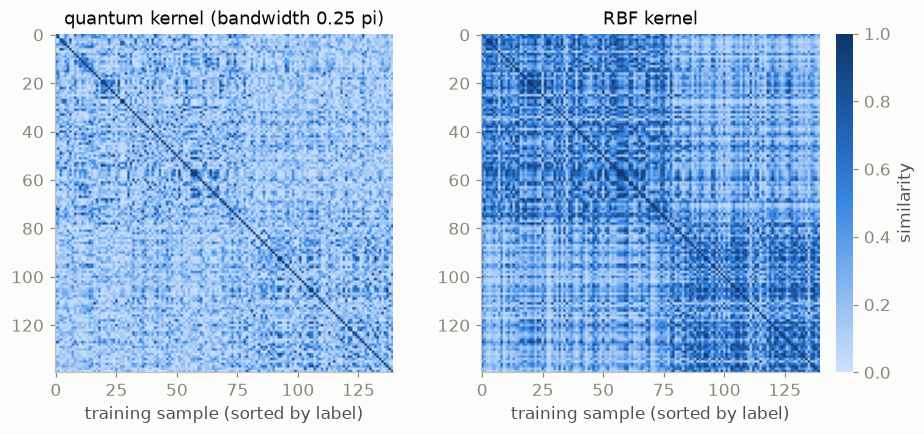

In [7]:
BANDWIDTH = np.pi / 4
angles_train = to_angles(train_x, train_x, BANDWIDTH)
angles_test = to_angles(test_x, train_x, BANDWIDTH)

k_quantum = quantum_kernel(angles_train)
k_rbf = rbf_kernel(angles_train)
order = np.argsort(train_y)  # sort by label so class blocks become visible

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.0))
for ax, matrix, title in (
    (axes[0], k_quantum[np.ix_(order, order)], "quantum kernel (bandwidth 0.25 pi)"),
    (axes[1], k_rbf[np.ix_(order, order)], "RBF kernel"),
):
    image = ax.imshow(matrix, cmap=qg.viz.sequential_cmap(), vmin=0, vmax=1)
    ax.set_title(title)
    ax.grid(False)
    ax.set_xlabel("training sample (sorted by label)")
bar = fig.colorbar(image, ax=axes, fraction=0.025, pad=0.02)
bar.set_label("similarity")
bar.outline.set_visible(False)
plt.show()

Both matrices show the same two-block structure — samples of the same class are
more similar to each other — which is what makes either kernel usable. The RBF
matrix is brighter overall: its mean off-diagonal similarity is 0.41 against
0.21 for the quantum kernel at this bandwidth.

## 5.3 The comparison

`compare_kernels` trains the same classifier on both kernel matrices and reports
both accuracies. The classifier is kernel ridge regression on labels mapped to
`+1` and `-1`, thresholded at zero — 15 lines, no scikit-learn. The kernel is
the only thing that differs.

In [8]:
comparison = compare_kernels(angles_train, train_y, angles_test, test_y)
for name in ("quantum", "rbf"):
    print(
        f"{name:>8}: train accuracy {comparison[name]['train_accuracy']:.3f}   "
        f"test accuracy {comparison[name]['test_accuracy']:.3f}"
    )
print("qubits used:", comparison["n_qubits"], "(one per feature)")
print("chance baseline:", round(majority, 3))

 quantum: train accuracy 1.000   test accuracy 0.950
     rbf: train accuracy 1.000   test accuracy 0.950
qubits used: 3 (one per feature)
chance baseline: 0.517


At this bandwidth both kernels reach 0.950 test accuracy against a 0.517 chance
baseline. The quantum kernel matches the classical one and does not beat it.
Three features and 140 training samples is a problem where a tuned classical
kernel is already at the noise floor of the data, so there is nothing left to
win. State that outcome as it is.

## 5.4 Bandwidth decides everything

The bandwidth is the angle range the features are mapped into. Sweep it and
hold everything else fixed.

In [9]:
bandwidths = [
    ("0.25 pi", np.pi / 4),
    ("0.50 pi", np.pi / 2),
    ("0.75 pi", 3 * np.pi / 4),
    ("1.00 pi", np.pi),
    ("1.50 pi", 1.5 * np.pi),
    ("2.00 pi", 2 * np.pi),
]

# similarity to the nearest neighbour in feature space, a direct readout of how
# far the feature map has spread the data
squared_distance = ((train_x[:, None, :] - train_x[None, :, :]) ** 2).sum(-1)
np.fill_diagonal(squared_distance, np.inf)
nearest = squared_distance.argmin(axis=1)

sweep = []
print(f"{'bandwidth':>10} {'Q train':>9} {'Q test':>8} {'RBF test':>9} "
      f"{'K(nearest)':>11} {'K off-diag':>11}")
for name, hi in bandwidths:
    a_train = to_angles(train_x, train_x, hi)
    a_test = to_angles(test_x, train_x, hi)
    scores = compare_kernels(a_train, train_y, a_test, test_y)
    matrix = quantum_kernel(a_train)
    off_diagonal = matrix[~np.eye(len(matrix), dtype=bool)]
    neighbour_similarity = float(matrix[np.arange(len(matrix)), nearest].mean())
    sweep.append((hi, scores, neighbour_similarity, float(off_diagonal.mean())))
    print(
        f"{name:>10} {scores['quantum']['train_accuracy']:>9.3f} "
        f"{scores['quantum']['test_accuracy']:>8.3f} {scores['rbf']['test_accuracy']:>9.3f} "
        f"{neighbour_similarity:>11.3f} {off_diagonal.mean():>11.3f}"
    )

 bandwidth   Q train   Q test  RBF test  K(nearest)  K off-diag


   0.25 pi     1.000    0.950     0.950       0.871       0.213
   0.50 pi     0.993    0.883     0.950       0.702       0.136
   0.75 pi     0.921    0.800     0.950       0.599       0.137
   1.00 pi     0.843    0.567     0.950       0.533       0.138
   1.50 pi     0.879    0.483     0.950       0.391       0.131
   2.00 pi     0.779    0.467     0.950       0.228       0.128


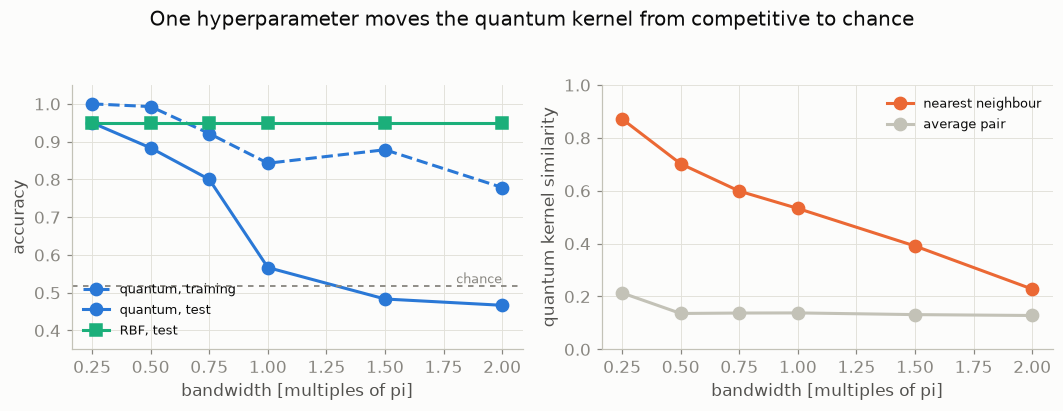

In [10]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.8, 3.6))
x_axis = [hi / np.pi for hi, _, _, _ in sweep]

left.plot(x_axis, [s["quantum"]["train_accuracy"] for _, s, _, _ in sweep],
          "o--", color=qg.viz.PALETTE[0], label="quantum, training")
left.plot(x_axis, [s["quantum"]["test_accuracy"] for _, s, _, _ in sweep],
          "o-", color=qg.viz.PALETTE[0], label="quantum, test")
left.plot(x_axis, [s["rbf"]["test_accuracy"] for _, s, _, _ in sweep],
          "s-", color=qg.viz.PALETTE[2], label="RBF, test")
left.axhline(majority, color=qg.viz.MUTED, lw=1.2, ls=(0, (3, 3)))
left.annotate("chance", (x_axis[-1], majority), ha="right", va="bottom",
              fontsize=8.5, color=qg.viz.MUTED)
left.set_xlabel("bandwidth [multiples of pi]")
left.set_ylabel("accuracy")
left.set_ylim(0.35, 1.05)
left.legend(loc="lower left", fontsize=8.5)

right.plot(x_axis, [n for _, _, n, _ in sweep], "o-", color=qg.viz.PALETTE[1],
           label="nearest neighbour")
right.plot(x_axis, [o for _, _, _, o in sweep], "o-", color=qg.viz.BASELINE,
           label="average pair")
right.set_xlabel("bandwidth [multiples of pi]")
right.set_ylabel("quantum kernel similarity")
right.set_ylim(0, 1)
right.legend(loc="upper right", fontsize=8.5)
fig.suptitle("One hyperparameter moves the quantum kernel from competitive to chance", y=1.03)
plt.tight_layout()
plt.show()

Read the two panels together, because the right one explains the left one.

On the left, the quantum kernel’s test accuracy falls from 0.950 at bandwidth
`0.25 pi` to 0.567 at `pi` and 0.467 at `2 pi` — from matching the classical
kernel to below the chance baseline of 0.517. Training accuracy stays high
throughout, at 0.779 even at the worst setting. A model that fits its training
data and generalizes at chance is the classic signature of a kernel matrix
collapsing toward the identity. The RBF baseline is flat at 0.950, because its
width is set by the median pairwise distance and is therefore unaffected by the
angle rescaling.

On the right is the mechanism. The average similarity between a training point
and its **nearest neighbour** in feature space drops from 0.871 to 0.228 as
bandwidth grows, while the average similarity over *all* pairs barely moves,
from 0.213 to 0.128. At `2 pi` a point’s closest neighbour looks no more similar
than a randomly chosen sample. The feature map has spread the states so far
apart that they are nearly orthogonal, the kernel matrix is nearly the identity,
and a kernel machine on an identity matrix memorizes the training set and
predicts nothing.

This is the finding of R. Shaydulin and S. M. Wild, “Importance of kernel
bandwidth in quantum machine learning”, Physical Review A 106, 042407, 2022,
arXiv:2111.05451, reproduced on a power system dataset. The practical rules that
follow:

* **Never report a quantum kernel result without reporting its bandwidth.** The
  same feature map and the same data give 0.950 or 0.467 depending on one number.
* **Tune the bandwidth the same way you tune the RBF width**, by
  cross-validation, or the comparison is not a comparison.
* **Report the training accuracy next to the test accuracy.** The gap between
  them is what exposes the collapse.
* **A quantum kernel that matches a tuned classical kernel is the expected
  outcome** at these sizes. Beating one requires a data set whose structure the
  feature map matches and a classical kernel cannot, and demonstrating that is a
  research result, not a default.

## 5.5 The generative counterpart: wind scenarios

Stochastic unit commitment and reserve sizing need **scenarios**: sampled
trajectories that reproduce the joint statistics of renewable output, not just
its marginal distribution at each hour. Ramps and hour-to-hour correlation are
what drive reserve requirements, so a generator that gets the means right and
the correlations wrong is useless.

`toy_wind_profiles` produces capacity factor trajectories with the structure
that matters: steady periods, ramp events, and autoregressive noise.

profiles: (300, 6)  capacity factor range (0.0, 1.0)


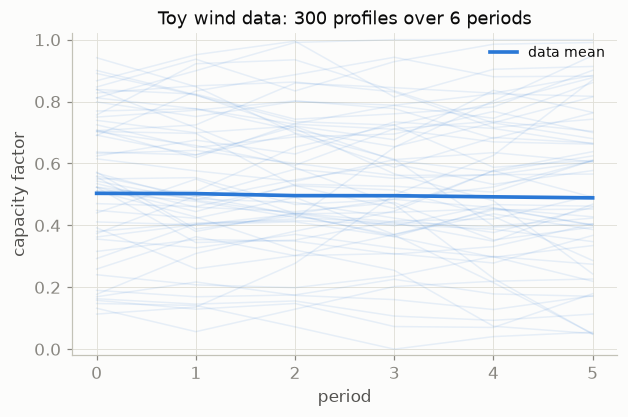

In [11]:
profiles = toy_wind_profiles(n_profiles=300, horizon=6, seed=0)
print("profiles:", profiles.shape, " capacity factor range",
      (round(float(profiles.min()), 3), round(float(profiles.max()), 3)))

qg.viz.plot_scenarios(profiles)
plt.gca().set_title("Toy wind data: 300 profiles over 6 periods")
plt.show()

The fan shows individual profiles; the thick line is the mean across profiles.
Some trajectories are flat and some ramp monotonically across the horizon, which
is the joint structure the model has to learn.

A **quantum Boltzmann machine** is a transverse-field Ising model used as a
probability distribution: each configuration of spins gets a probability from
the thermal state of the Hamiltonian, and training adjusts the fields and
couplings until the model’s moments match the data’s. QuGrid computes the
thermal state by exact diagonalization, which is trustworthy up to 12 units and
makes the hardware argument concrete — sampling is the bottleneck, and that is
exactly where an annealer or a gate-model device would enter.

The model is binary, so the profiles are thresholded at their global median:
1 means “output above the median in this period”.

In [12]:
bits = binarize(profiles)
print("threshold (global median):", round(float(np.median(profiles)), 4))
print("binary data:", bits.shape)

statistics = empirical_statistics(bits)
print("mean activation per period:", statistics["means"])
print("neighbour correlations    :", statistics["neighbor_corr"])

threshold (global median): 0.4915
binary data: (300, 6)
mean activation per period: [0.5267 0.5033 0.4933 0.4867 0.5133 0.4767]
neighbour correlations    : [0.8342 0.8335 0.7867 0.7879 0.8491]


moment mismatch: 1.7586 at the start, 0.0123 after training
parameters: 21 (6 local fields, 15 couplings)


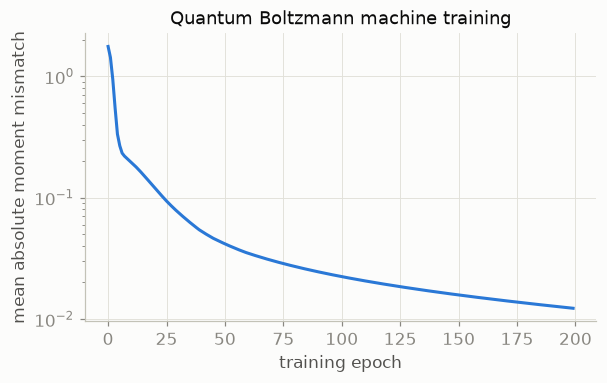

In [13]:
machine = QuantumBoltzmannMachine(n_visible=6, gamma=0.5, beta=1.0, seed=0)
mismatch = machine.fit(bits, epochs=200, lr=0.15)
print(f"moment mismatch: {mismatch[0]:.4f} at the start, {mismatch[-1]:.4f} after training")
print("parameters:", machine.n + machine.n * (machine.n - 1) // 2,
      "(6 local fields, 15 couplings)")

fig, ax = plt.subplots(figsize=(6.0, 3.4))
ax.semilogy(mismatch, color=qg.viz.PALETTE[0])
ax.set_xlabel("training epoch")
ax.set_ylabel("mean absolute moment mismatch")
ax.set_title("Quantum Boltzmann machine training")
plt.show()

The mismatch is the quantity the update rule provably decreases, following
M. H. Amin et al., “Quantum Boltzmann Machine”, Physical Review X 8, 021050,
2018, arXiv:1601.02036. It falls by two orders of magnitude and flattens, which
is the expected shape: the model has 21 parameters and cannot match every moment
of the data exactly.

The test is whether samples drawn from the trained model reproduce the
statistics that scenario users care about.

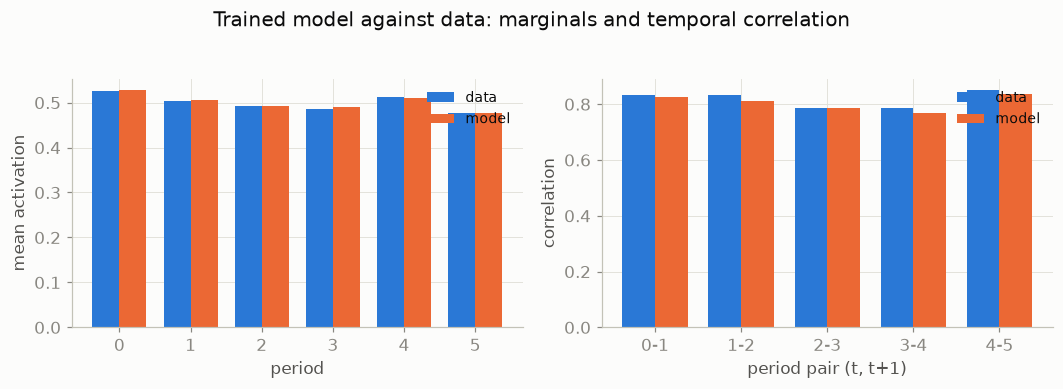

In [14]:
comparison = machine.compare_statistics(bits, n_samples=2000, seed=1)
periods = np.arange(6)

fig, (left, right) = plt.subplots(1, 2, figsize=(9.8, 3.4))
width = 0.38
left.bar(periods - width / 2, comparison["data"]["means"], width, label="data",
         color=qg.viz.PALETTE[0])
left.bar(periods + width / 2, comparison["model"]["means"], width, label="model",
         color=qg.viz.PALETTE[1])
left.set_xlabel("period")
left.set_ylabel("mean activation")
left.set_xticks(periods)
left.legend(fontsize=9)

lags = np.arange(5)
right.bar(lags - width / 2, comparison["data"]["neighbor_corr"], width, label="data",
          color=qg.viz.PALETTE[0])
right.bar(lags + width / 2, comparison["model"]["neighbor_corr"], width, label="model",
          color=qg.viz.PALETTE[1])
right.set_xlabel("period pair (t, t+1)")
right.set_ylabel("correlation")
right.set_xticks(lags, [f"{t}-{t + 1}" for t in lags])
right.legend(fontsize=9)
fig.suptitle("Trained model against data: marginals and temporal correlation", y=1.03)
plt.tight_layout()
plt.show()

In [15]:
mean_error = np.abs(comparison["data"]["means"] - comparison["model"]["means"]).max()
corr_error = np.abs(
    comparison["data"]["neighbor_corr"] - comparison["model"]["neighbor_corr"]
).max()
print("largest error in mean activation :", round(float(mean_error), 4))
print("largest error in correlation     :", round(float(corr_error), 4))

model_distribution = machine.state_probabilities()
pattern_index = (bits * (2 ** np.arange(6))).sum(axis=1)
empirical = np.bincount(pattern_index, minlength=64) / len(bits)
total_variation = 0.5 * np.abs(model_distribution - empirical).sum()
print("total variation distance over all 64 patterns:", round(float(total_variation), 4))

largest error in mean activation : 0.0033
largest error in correlation     : 0.0212
total variation distance over all 64 patterns: 0.0631


The marginals match to within 0.003 and the neighbour correlations to within
0.021, so the model reproduces both the level and the temporal structure. Across
the full distribution over all 64 binary patterns, the total variation distance
to the empirical histogram is 0.063 — from 21 parameters against the 63 free
parameters an unrestricted distribution over 64 patterns would need.

That compression ratio is the argument for the model class. It is not yet an
argument for quantum hardware: at six units the thermal state is a 64-by-64
matrix exponential, which NumPy computes in milliseconds. The argument for
hardware begins where `2^n` stops fitting in memory, at a few dozen periods or a
few dozen wind farms, and it depends entirely on whether sampling from the
thermal state is the actual bottleneck for that problem.

## 5.6 When is quantum machine learning worth studying for grid tasks

Take the two experiments above as the evidence.

**Studying it is reasonable when:**

* The feature count is small and physically meaningful. Kernel methods here use
  one qubit per feature, so three load multipliers fit and a 500-bus state
  estimate does not.
* The question is about the method, not about beating a baseline: how bandwidth
  interacts with feature dimension, which feature maps suit power system data,
  how a kernel behaves as the network grows.
* The task is generative and the joint structure is the point. Scenario
  generation, where correlation and ramp structure matter more than marginals,
  is a better fit for these models than classification is.
* You need resource estimates for a future machine. Those can be computed now.

**It is not reasonable when:**

* The classical baseline is already at the noise floor, as in section 5.3.
* The data set is large. Every kernel method needs the full pairwise kernel
  matrix, which is quadratic in the sample count regardless of how each entry is
  computed, and on hardware each entry needs its own circuit and its own shots.
* The claim under test is a speedup. Nothing in this notebook, and nothing in
  the current literature on grid data sets, supports one.

**The standard that makes a result publishable** is the same one this notebook
applies: a tuned classical kernel beside the quantum one, both hyperparameters
selected the same way, training accuracy reported next to test accuracy, and the
chance baseline printed alongside.

## 5.7 Summary

* `screening_dataset(net, ...)` builds an N-1 security classification task from
  any network, labelled by exact DC power flow over every connected contingency.
* A quantum kernel is a similarity matrix built from state overlaps, and it
  drops into any kernel machine unchanged.
* Bandwidth — the angle range the features are mapped into — moved test accuracy
  from 0.950 to 0.467 on this data set while training accuracy stayed high.
  Report it, tune it, and report the training accuracy beside the test accuracy.
* A quantum Boltzmann machine with 21 parameters reproduced the wind data’s
  marginals to 0.003 and its neighbour correlations to 0.021, at a total
  variation distance of 0.063 from the empirical distribution.

That completes the series. Notebook 1 covered the encoding and solver layers,
notebook 2 the construction of encodings, notebook 3 quantum optimization,
notebook 4 quantum linear solvers, and this notebook quantum machine learning.